# Wijnclassificatie met een neural network

In deze notebook voorspellen we of een wijn **rood** of **wit** is op basis van de kenmerken uit de dataset.

De code is simpeler gemaakt door:

- duidelijke namen te gebruiken;
- herhaling te verminderen met functies;
- de data maar één keer te splitsen;
- standaardisatie netjes binnen elk experiment toe te passen;
- alle resultaten in één overzichtelijke tabel te zetten.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense


## 2. Instellingen

Door belangrijke instellingen bovenaan te zetten, kun je ze makkelijk aanpassen.

In [13]:
RANDOM_STATE = 45
TEST_SIZE = 0.34

RED_WINE_FILE = "redwinequality.csv"
WHITE_WINE_FILE = "whitewinequality.csv"


## 3. Data laden

We voegen een extra kolom `type` toe:

- `1` = rode wijn
- `0` = witte wijn

In [14]:
def laad_wijn_data(red_file, white_file):
    # Laad rode en witte wijn en voeg ze samen tot één dataset
    red = pd.read_csv(red_file, sep=";")
    white = pd.read_csv(white_file, sep=";")

    red["type"] = 1
    white["type"] = 0

    wines = pd.concat([red, white], ignore_index=True)
    wines = wines.dropna()

    return wines


wines = laad_wijn_data(RED_WINE_FILE, WHITE_WINE_FILE)
wines.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


## 4. Korte controle van de data

In [15]:
print(f"Aantal rijen: {wines.shape[0]}")
print(f"Aantal kolommen: {wines.shape[1]}")

wines["type"].value_counts().rename(index={0: "Witte wijn", 1: "Rode wijn"})

Aantal rijen: 6497
Aantal kolommen: 13


type
Witte wijn    4898
Rode wijn     1599
Name: count, dtype: int64

## 5. Alcoholverdeling bekijken

Deze grafiek laat zien hoe het alcoholpercentage verdeeld is bij rode en witte wijn.

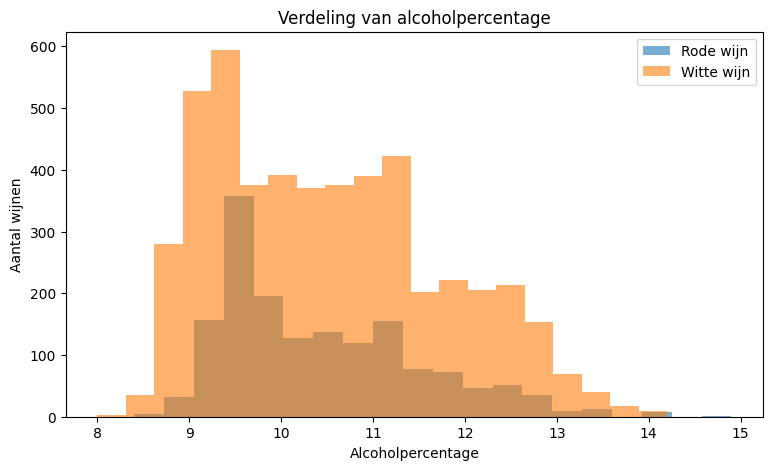

In [16]:
plt.figure(figsize=(9, 5))

for wine_type, label in [(1, "Rode wijn"), (0, "Witte wijn")]:
    alcohol = wines.loc[wines["type"] == wine_type, "alcohol"]
    plt.hist(alcohol, bins=20, alpha=0.6, label=label)

plt.title("Verdeling van alcoholpercentage")
plt.xlabel("Alcoholpercentage")
plt.ylabel("Aantal wijnen")
plt.legend()
plt.show()


## 6. Input en target maken

`X` bevat de kenmerken van de wijn.
`y` bevat wat we willen voorspellen: rood of wit.

In [17]:
X = wines.drop(columns="type")
y = wines["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Trainingsdata:", X_train.shape)
print("Testdata:", X_test.shape)

Trainingsdata: (4288, 12)
Testdata: (2209, 12)


## 7. Hulpfuncties voor het model

Deze functies maken de rest van de notebook korter en duidelijker.

In [18]:
def zet_seed(seed=RANDOM_STATE):
    # Zorgt ervoor dat experimenten beter vergelijkbaar zijn
    np.random.seed(seed)
    tf.random.set_seed(seed)


def maak_model(input_dim, lagen=(12, 9), optimizer="adam"):
    # Maak een simpel neural network voor binaire classificatie
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for aantal_neuronen in lagen:
        model.add(Dense(aantal_neuronen, activation="relu"))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def bereken_scores(model, X_test_data, y_test_data):
    # Bereken de belangrijkste scores van een getraind model
    loss, _ = model.evaluate(X_test_data, y_test_data, verbose=0)

    kansen = model.predict(X_test_data, verbose=0)
    voorspellingen = (kansen > 0.5).astype(int).flatten()

    return {
        "loss": round(loss, 4),
        "accuracy": round(accuracy_score(y_test_data, voorspellingen), 4),
        "precision": round(precision_score(y_test_data, voorspellingen, zero_division=0), 4),
        "recall": round(recall_score(y_test_data, voorspellingen, zero_division=0), 4),
        "f1_score": round(f1_score(y_test_data, voorspellingen, zero_division=0), 4)
    }

## 8. Eén basismodel trainen

Eerst trainen we één model, zodat duidelijk is hoe het proces werkt.

In [19]:
zet_seed()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

basis_model = maak_model(input_dim=X_train_scaled.shape[1], lagen=(12, 9), optimizer="adam")

basis_model.fit(
    X_train_scaled,
    y_train,
    epochs=5,
    batch_size=16,
    verbose=1
)

basis_scores = bereken_scores(basis_model, X_test_scaled, y_test)
basis_scores


Epoch 1/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8463 - loss: 0.3965
Epoch 2/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9939 - loss: 0.0576
Epoch 3/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9956 - loss: 0.0295
Epoch 4/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9960 - loss: 0.0233
Epoch 5/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0205


{'loss': 0.041,
 'accuracy': 0.9909,
 'precision': 0.987,
 'recall': 0.9761,
 'f1_score': 0.9815}

## 9. Voorbeelden van voorspellingen

In [20]:
kansen = basis_model.predict(X_test_scaled, verbose=0)
voorspellingen = (kansen > 0.5).astype(int).flatten()

voorbeeld_df = pd.DataFrame({
    "echte_waarde": y_test.iloc[:12].map({0: "Witte wijn", 1: "Rode wijn"}).values,
    "voorspelling": pd.Series(voorspellingen[:12]).map({0: "Witte wijn", 1: "Rode wijn"}).values,
    "kans_op_rood": kansen[:12].flatten().round(3)
})

voorbeeld_df["goed_voorspeld"] = voorbeeld_df["echte_waarde"] == voorbeeld_df["voorspelling"]
voorbeeld_df

,echte_waarde,voorspelling,kans_op_rood,goed_voorspeld
0,Witte wijn,Witte wijn,0.001,True
1,Witte wijn,Witte wijn,0.000,True
2,Witte wijn,Witte wijn,0.000,True
3,Rode wijn,Rode wijn,0.996,True
4,Witte wijn,Witte wijn,0.000,True
5,Rode wijn,Rode wijn,1.000,True
6,Rode wijn,Rode wijn,1.000,True
7,Witte wijn,Witte wijn,0.016,True
8,Witte wijn,Witte wijn,0.002,True
9,Witte wijn,Witte wijn,0.008,True


## 10. Meerdere experimenten draaien

Hier testen we meerdere instellingen. Daardoor kun je in één tabel zien welk model het beste werkt.

In [21]:
experimenten = [
    {
        "naam": "Baseline",
        "lagen": (12, 9),
        "epochs": 5,
        "batch_size": 16,
        "optimizer": "adam",
        "standaardiseren": True
    },
    {
        "naam": "Meer epochs",
        "lagen": (12, 9),
        "epochs": 10,
        "batch_size": 16,
        "optimizer": "adam",
        "standaardiseren": True
    },
    {
        "naam": "Grotere batch size",
        "lagen": (12, 9),
        "epochs": 10,
        "batch_size": 32,
        "optimizer": "adam",
        "standaardiseren": True
    },
    {
        "naam": "Kleiner model",
        "lagen": (8,),
        "epochs": 10,
        "batch_size": 16,
        "optimizer": "adam",
        "standaardiseren": True
    },
    {
        "naam": "Groter model",
        "lagen": (32, 16, 8),
        "epochs": 10,
        "batch_size": 16,
        "optimizer": "adam",
        "standaardiseren": True
    },
    {
        "naam": "Zonder standaardisatie",
        "lagen": (12, 9),
        "epochs": 10,
        "batch_size": 16,
        "optimizer": "adam",
        "standaardiseren": False
    },
    {
        "naam": "RMSprop optimizer",
        "lagen": (12, 9),
        "epochs": 10,
        "batch_size": 16,
        "optimizer": "rmsprop",
        "standaardiseren": True
    }
]

In [22]:
def bereid_data_voor(standaardiseren):
    # Standaardiseer de data alleen als het experiment dat vraagt
    if not standaardiseren:
        return X_train.values, X_test.values

    scaler = StandardScaler()
    X_train_ready = scaler.fit_transform(X_train)
    X_test_ready = scaler.transform(X_test)

    return X_train_ready, X_test_ready


def draai_experiment(experiment):
    # Train één experiment en geef de resultaten terug als dictionary
    zet_seed()

    X_train_ready, X_test_ready = bereid_data_voor(experiment["standaardiseren"])

    model = maak_model(
        input_dim=X_train_ready.shape[1],
        lagen=experiment["lagen"],
        optimizer=experiment["optimizer"]
    )

    model.fit(
        X_train_ready,
        y_train,
        epochs=experiment["epochs"],
        batch_size=experiment["batch_size"],
        verbose=0
    )

    scores = bereken_scores(model, X_test_ready, y_test)

    return {
        "experiment": experiment["naam"],
        "lagen": str(experiment["lagen"]),
        "epochs": experiment["epochs"],
        "batch_size": experiment["batch_size"],
        "optimizer": experiment["optimizer"],
        "standaardiseren": "Ja" if experiment["standaardiseren"] else "Nee",
        **scores
    }


resultaten = []

for nummer, experiment in enumerate(experimenten, start=1):
    print(f"Experiment {nummer}/{len(experimenten)}: {experiment['naam']}")
    resultaten.append(draai_experiment(experiment))

resultaten_df = pd.DataFrame(resultaten)
resultaten_df = resultaten_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

resultaten_df


Experiment 1/7: Baseline
Experiment 2/7: Meer epochs
Experiment 3/7: Grotere batch size
Experiment 4/7: Kleiner model
Experiment 5/7: Groter model
Experiment 6/7: Zonder standaardisatie
Experiment 7/7: RMSprop optimizer


,experiment,lagen,epochs,batch_size,optimizer,standaardiseren,loss,accuracy,precision,recall,f1_score
0,Groter model,"(32, 16, 8)",10,16,adam,Ja,0.0361,0.9946,0.9926,0.9853,0.9889
1,Grotere batch size,"(12, 9)",10,32,adam,Ja,0.0352,0.9941,0.9944,0.9816,0.9880
2,Baseline,"(12, 9)",5,16,adam,Ja,0.0354,0.9932,0.9907,0.9816,0.9861
3,Meer epochs,"(12, 9)",10,16,adam,Ja,0.0329,0.9919,0.9852,0.9816,0.9834
4,RMSprop optimizer,"(12, 9)",10,16,rmsprop,Ja,0.0471,0.9919,0.9888,0.9779,0.9834
5,Kleiner model,"(8,)",10,16,adam,Ja,0.0414,0.9909,0.9852,0.9779,0.9815
6,Zonder standaardisatie,"(12, 9)",10,16,adam,Nee,0.1412,0.9525,0.9680,0.8346,0.8963


## 11. Beste experiment kiezen

Het beste experiment wordt gekozen op basis van de hoogste accuracy. Bij gelijke accuracy kun je ook naar de F1-score kijken.

In [23]:
beste = resultaten_df.iloc[0]

print("Beste experiment")
print("----------------")
print(f"Naam: {beste['experiment']}")
print(f"Accuracy: {beste['accuracy']}")
print(f"F1-score: {beste['f1_score']}")
print(f"Loss: {beste['loss']}")
print()
print("Instellingen:")
print(f"Lagen: {beste['lagen']}")
print(f"Epochs: {beste['epochs']}")
print(f"Batch size: {beste['batch_size']}")
print(f"Optimizer: {beste['optimizer']}")
print(f"Standaardiseren: {beste['standaardiseren']}")

Beste experiment
----------------
Naam: Groter model
Accuracy: 0.9946
F1-score: 0.9889
Loss: 0.0361

Instellingen:
Lagen: (32, 16, 8)
Epochs: 10
Batch size: 16
Optimizer: adam
Standaardiseren: Ja


## 12. Conclusie

In de resultatentabel kun je snel vergelijken welk experiment het beste presteert.

Meestal werkt standaardisatie goed bij neural networks, omdat alle inputwaarden dan op vergelijkbare schaal staan. Een groter model kan beter worden, maar dat is niet altijd zo. Soms wordt een groter model juist minder goed, omdat het te veel op de trainingsdata gaat lijken.